<a href="https://colab.research.google.com/github/RizkiHadiono/PCVK_Ganjil_25-26/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'MOKHAMAD RIZKI HADIONO SINGGIH'
NIM = '244107020198'

N = int(NIM[-3:])
PARAM = {
    'b': (N % 61) + 20,
    'a': round(1.0 + (N % 9) / 10, 1),
    'c': (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit': (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s: %s' % (k, v))
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA  : MOKHAMAD RIZKI HADIONO SINGGIH
NIM   : 244107020198 | N = 198
b     : 35
a     : 1.0
c     : 48
gamma : 0.4
bit   : 2
WAKTU : 2026-09-17 18:23:16 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 23602b457f82417a


In [16]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

BASE_DIR = '/content/drive/MyDrive/PCVK P3/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


PRAKTIKUM
Linear Brightness

Linear Brightness digunakan untuk membuat citra lebih terang atau lebih gelap dengan menambahkan nilai b pada setiap pixel.

Rumus:

$$ g(x,y)=f(x,y)+b $$

Untuk NIM, nilai b = 35.

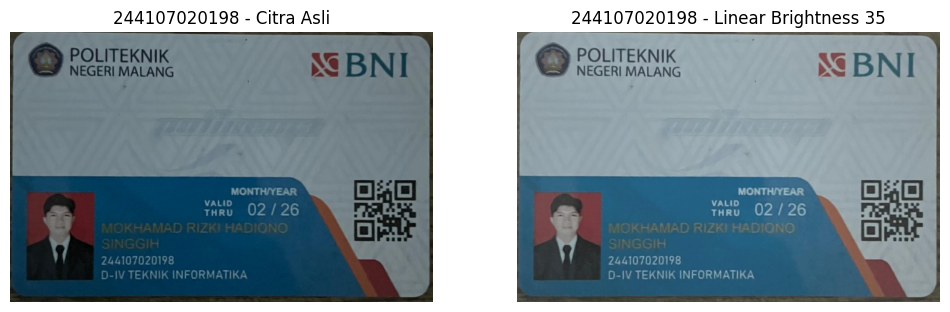

In [17]:
brightness = PARAM['b']

original = cv.imread(BASE_DIR + 'KTM1a.jpeg')

brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):

            nilai = int(original[y, x, c]) + brightness

            if nilai > 255:
                nilai = 255

            if nilai < 0:
                nilai = 0

            brightness_image[y, x, c] = nilai

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(brightness_image, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Linear Brightness ' + str(brightness))
plt.axis('off')

plt.show()

Tugas Praktikum 1 — Inverse


Inverse digunakan untuk membalik nilai intensitas pixel. Pixel yang awalnya terang menjadi gelap, sedangkan pixel yang gelap menjadi terang.

Rumus:

$$ g(x)=255-f(x) $$

Pada tugas ini digunakan KTM1a.jpg dan KTM1b.jpg, kemudian hasilnya dibandingkan dengan gambar asli.

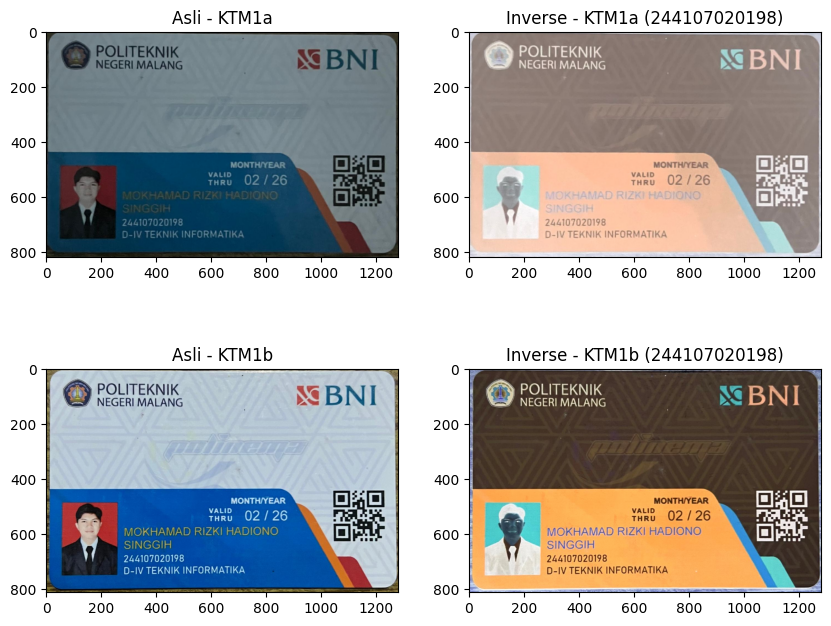

In [18]:
# Baca citra
img_ktm1a = cv.cvtColor(
    cv.imread(BASE_DIR + 'KTM1a.jpeg'),
    cv.COLOR_BGR2RGB
)

img_ktm1b = cv.cvtColor(
    cv.imread(BASE_DIR + 'KTM1b.jpeg'),
    cv.COLOR_BGR2RGB
)

# Operasi Inverse
inv_ktm1a = 255 - img_ktm1a
inv_ktm1b = 255 - img_ktm1b

# Visualisasi
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0,0].imshow(img_ktm1a)
ax[0,0].set_title('Asli - KTM1a')

ax[0,1].imshow(inv_ktm1a)
ax[0,1].set_title(f'Inverse - KTM1a ({NIM})')

ax[1,0].imshow(img_ktm1b)
ax[1,0].set_title('Asli - KTM1b')

ax[1,1].imshow(inv_ktm1b)
ax[1,1].set_title(f'Inverse - KTM1b ({NIM})')

plt.show()

Hasil :
Pada KTM1a yang diambil di ruangan gelap, hasil inverse dapat terlihat pucat atau berkabut karena sebagian besar nilai pixel awalnya rendah. Sedangkan KTM1b yang memiliki pencahayaan ruangan lebih baik cenderung masih memiliki perbedaan intensitas yang lebih jelas.

Tugas Praktikum 2 — Contrast

Contrast digunakan untuk mengubah perbedaan antara bagian terang dan gelap pada citra.

Rumus yang digunakan:

$$ g(x,y)=a\times f(x,y)+b $$

Pada tugas ini menggunakan:

a = PARAM['a']

Untuk NIM, a = 1.0.

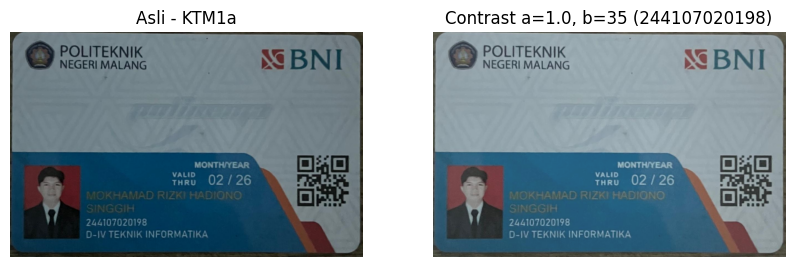

In [19]:
a_val = PARAM['a']
b_val = PARAM['b']

img_ktm1a = cv.cvtColor(
    cv.imread(BASE_DIR + 'KTM1a.jpeg'),
    cv.COLOR_BGR2RGB
)

contrast_img = np.clip(
    a_val * img_ktm1a.astype(np.float32) + b_val,
    0,
    255
).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_ktm1a)
plt.title('Asli - KTM1a')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contrast_img)
plt.title(f'Contrast a={a_val}, b={b_val} ({NIM})')
plt.axis('off')

plt.show()

Tugas Praktikum 3 — Logarithmic Brightness

Logarithmic Brightness digunakan untuk meningkatkan bagian citra yang memiliki intensitas rendah. Rumus yang digunakan:

$$ s=c\log(1+r) $$

Pada tugas ini nilai c berasal dari parameter NIM. Untuk NIM:

c = 38

Kemudian hasilnya dibandingkan dengan Linear Brightness menggunakan b = 35.

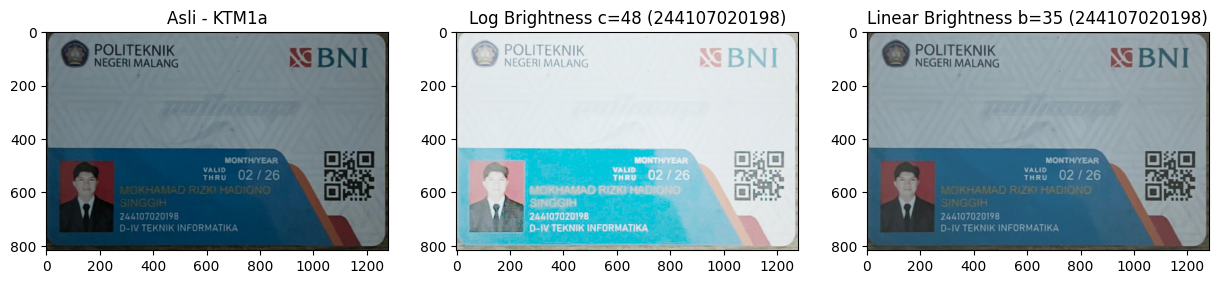

In [20]:
c_val = PARAM['c']

# Membaca citra
img_ktm1a = cv.cvtColor(
    cv.imread(BASE_DIR + 'KTM1a.jpeg'),
    cv.COLOR_BGR2RGB
)

# Transformasi Logaritma
log_img = c_val * np.log1p(
    img_ktm1a.astype(np.float32)
)

log_img = np.clip(
    log_img,
    0,
    255
).astype(np.uint8)

# Visualisasi
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img_ktm1a)
ax[0].set_title('Asli - KTM1a')

ax[1].imshow(log_img)
ax[1].set_title(
    f'Log Brightness c={c_val} ({NIM})'
)

ax[2].imshow(contrast_img)
ax[2].set_title(
    f'Linear Brightness b={b_val} ({NIM})'
)

plt.show()

Tugas Praktikum 4 — Grayscale

Grayscale mengubah citra berwarna menjadi citra dengan satu kanal intensitas. Modul meminta tiga metode:

Averaging
Lightness
Luminance

Metode luminance menggunakan:

$$ 0.21R+0.72G+0.07B $$

Tugas menggunakan KTM1c.jpg.

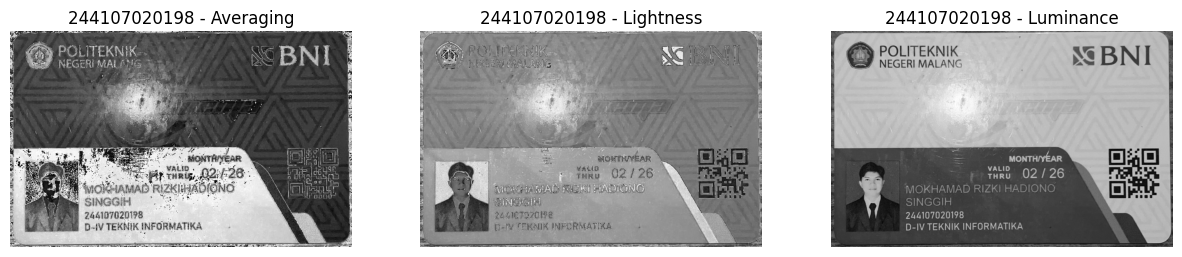

Averaging : 38.512107600165216 25.97751648742799
Lightness : 68.70776457946097 18.050485071091213
Luminance : 137.9427444431536 63.75968779937277


In [24]:
img = cv.cvtColor(cv.imread(BASE_DIR + 'KTM1c.jpeg'), cv.COLOR_BGR2RGB)

R, G, B = cv.split(img)

averaging = (R + G + B) / 3
lightness = (np.max(img, axis=2) + np.min(img, axis=2)) / 2
luminance = 0.21*R + 0.72*G + 0.07*B

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(averaging, cmap='gray')
plt.title(NIM + ' - Averaging')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(lightness, cmap='gray')
plt.title(NIM + ' - Lightness')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(luminance, cmap='gray')
plt.title(NIM + ' - Luminance')
plt.axis('off')

plt.show()

print('Averaging :', np.mean(averaging), np.std(averaging))
print('Lightness :', np.mean(lightness), np.std(lightness))
print('Luminance :', np.mean(luminance), np.std(luminance))

Tugas 5 — Color Isolator

Mempertahankan warna tertentu pada OBJ1.jpeg, sedangkan bagian lainnya dibuat grayscale. Modul meminta menggunakan HSV dan mencoba range yang berbeda.

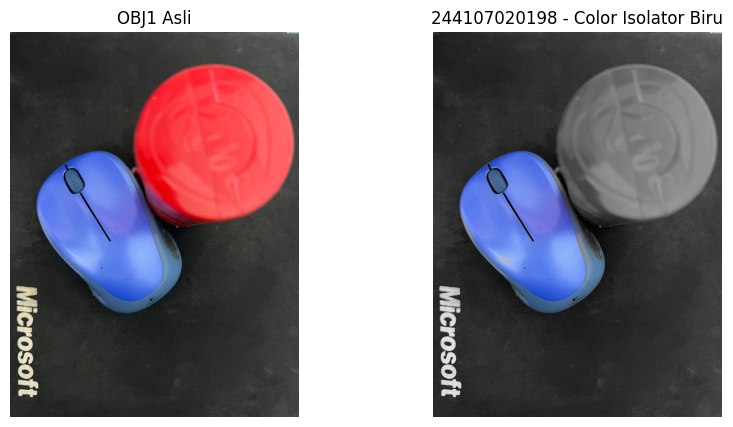

In [26]:
img = cv.imread(BASE_DIR + 'OBJ1.jpeg')
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

mask = cv.inRange(hsv, np.array([90,100,100]), np.array([130,255,255]))

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

hasil = np.where(mask[:,:,None] > 0, img, gray)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('OBJ1 Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Color Isolator Biru')
plt.axis('off')

plt.show()

Tugas 6 — Gamma Correction

Penjelasan: Gamma Correction digunakan untuk mengubah intensitas citra. Modul meminta mencoba minimal 5 nilai gamma. Rumus modul menggunakan pangkat 1/gamma.

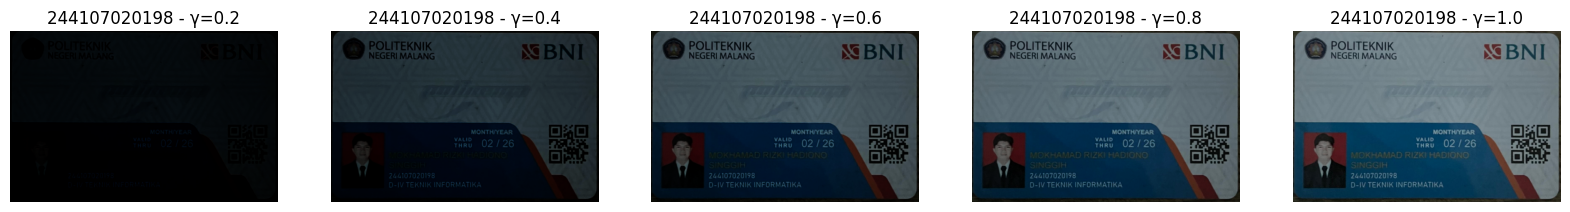

In [27]:
img = cv.imread(BASE_DIR + 'KTM1a.jpeg')
gammas = [0.2, 0.4, 0.6, 0.8, 1.0]

plt.figure(figsize=(20,4))

for i, gamma in enumerate(gammas):
    hasil = 255 * (img / 255) ** (1/gamma)
    hasil = hasil.astype(np.uint8)

    plt.subplot(1,5,i+1)
    plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - γ=' + str(gamma))
    plt.axis('off')

plt.show()

Tugas 7 — Bit Depth

Mensimulasikan kedalaman bit dari 1 sampai 7 bit. Modul menggunakan rumus level = 255/(2^bit - 1).

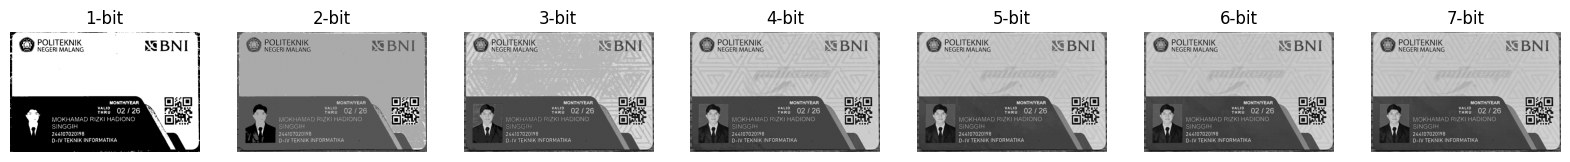

In [31]:
img = cv.imread(BASE_DIR + 'KTM1b.jpeg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(20,4))

for bit in range(1,8):
    level = 255 / (2**bit - 1)
    hasil = np.round(gray / level) * level
    hasil = hasil.astype(np.uint8)

    plt.subplot(1,7,bit)
    plt.imshow(hasil, cmap='gray')
    plt.title(str(bit) + '-bit')
    plt.axis('off')

plt.show()

Tugas 8 — Average Denoising & PSNR

Beberapa gambar noise dirata-ratakan, kemudian hasilnya dibandingkan dengan gambar asli menggunakan PSNR. Modul meminta 10, 20, 40, 80, dan 100 gambar.

10 gambar = 19.74 dB
20 gambar = 19.84 dB
40 gambar = 19.89 dB
80 gambar = 19.92 dB
100 gambar = 19.92 dB


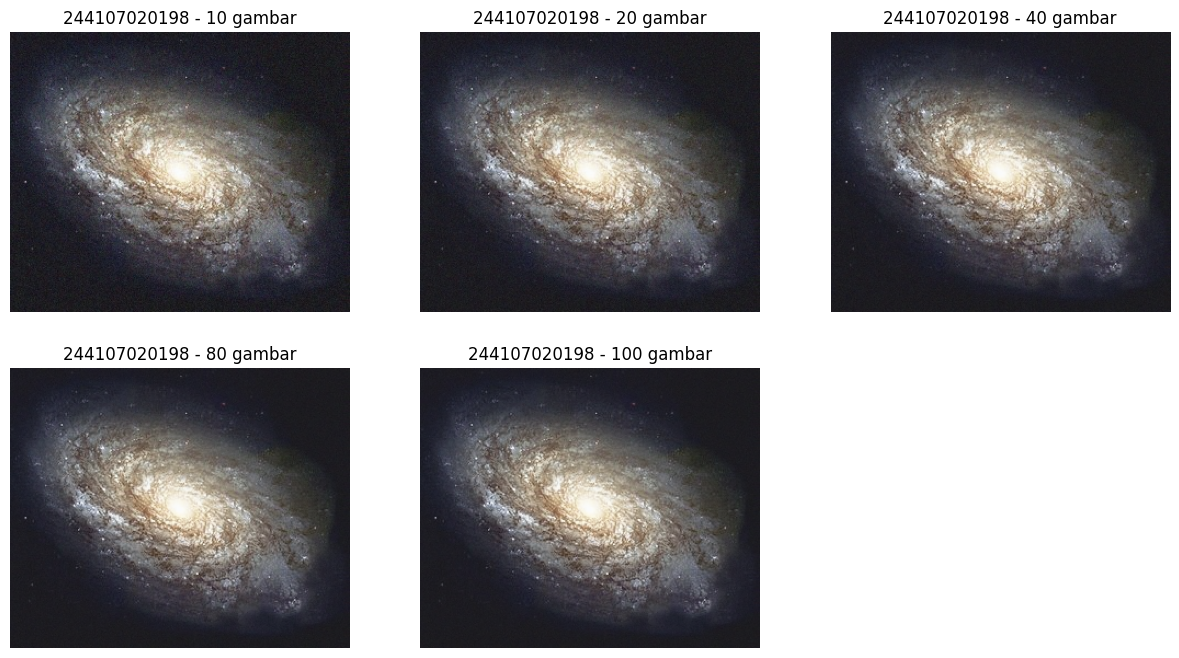

In [35]:
from math import log10, sqrt

def PSNR(a, b):
    mse = np.mean((a.astype(float) - b.astype(float))**2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255 / sqrt(mse))

original = cv.imread(BASE_DIR + 'galaxy.jpg')

images = []

for file in glob.glob(BASE_DIR + 'noises/*.jpg'):
    images.append(cv.imread(file))

plt.figure(figsize=(15, 8))

for i, jumlah in enumerate([10, 20, 40, 80, 100]):
    hasil = np.mean(images[:jumlah], axis=0).astype(np.uint8)

    print(jumlah, 'gambar =', round(PSNR(original, hasil), 2), 'dB')

    plt.subplot(2, 3, i + 1)
    plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + str(jumlah) + ' gambar')
    plt.axis('off')

plt.show()

Tugas 9 — Image Masking

Membuat mask untuk menutupi bagian wajah dan NIM pada KTM1d.jpeg. Modul meminta menggunakan operasi logika seperti AND, OR, NOT, NAND, dan XOR.

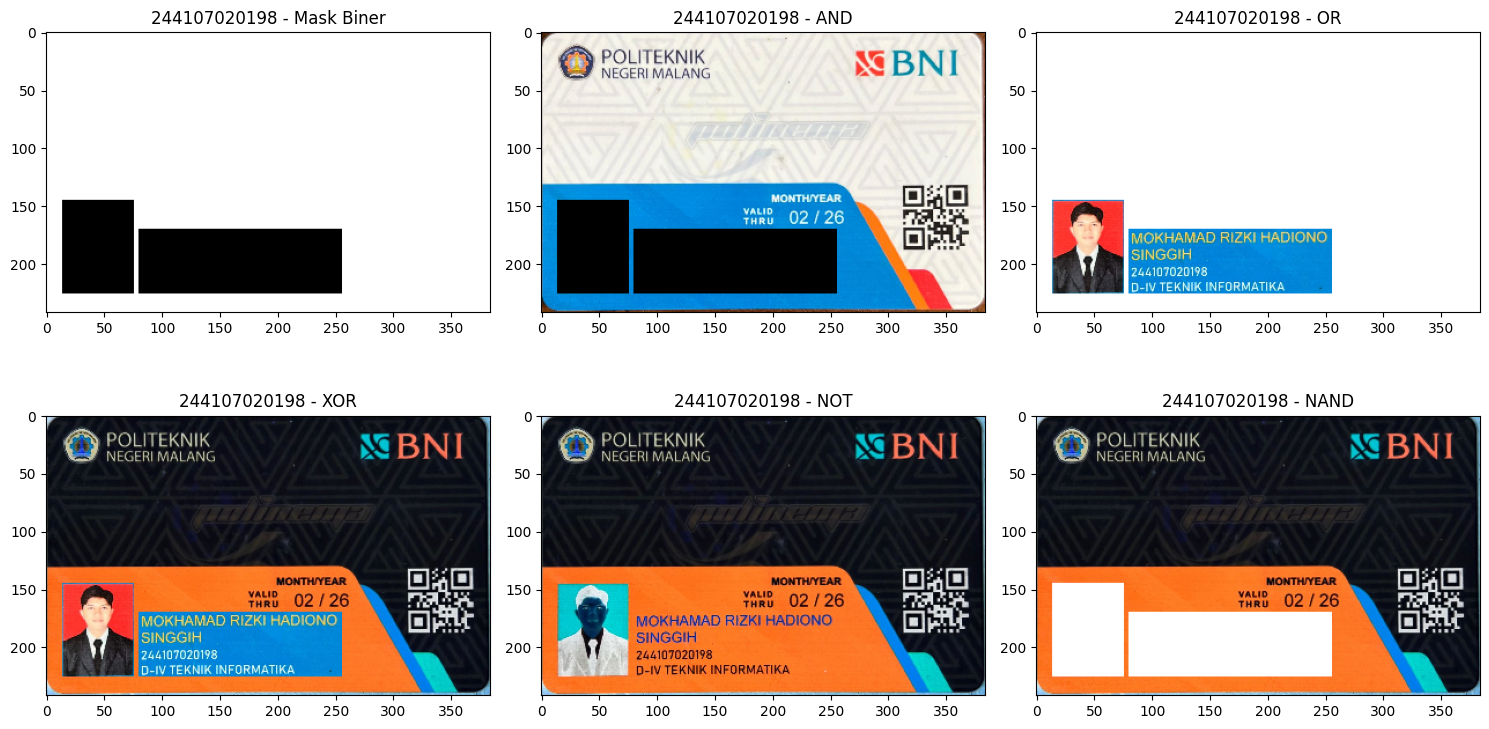

In [58]:
# Buat mask awal warna putih
mask = np.ones((h, w), dtype=np.uint8) * 255

# Sensor wajah
cv.rectangle(mask, (14, 145), (75, 225), 0, -1)

# Sensor nama + NIM
cv.rectangle(mask, (80, 170), (255, 225), 0, -1)

# Mask menjadi 3 channel
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

# Operator logika
hasil_and  = cv.bitwise_and(img, mask_3ch)
hasil_or   = cv.bitwise_or(img, mask_3ch)
hasil_xor  = cv.bitwise_xor(img, mask_3ch)
hasil_not  = cv.bitwise_not(img)
hasil_nand = cv.bitwise_not(hasil_and)

# Tampilkan
daftar_operasi = [
    ('Mask Biner', mask),
    ('AND', hasil_and),
    ('OR', hasil_or),
    ('XOR', hasil_xor),
    ('NOT', hasil_not),
    ('NAND', hasil_nand)
]

plt.figure(figsize=(15, 8))

for i, (nama, gambar) in enumerate(daftar_operasi, 1):
    plt.subplot(2, 3, i)

    if len(gambar.shape) == 2:
        plt.imshow(gambar, cmap='gray')
    else:
        plt.imshow(cv.cvtColor(gambar, cv.COLOR_BGR2RGB))

    plt.title(f'{NIM} - {nama}')

    # Ruler / koordinat tanpa grid di dalam foto
    plt.xticks(np.arange(0, w + 1, 50))
    plt.yticks(np.arange(0, h + 1, 50))
    plt.grid(False)

plt.tight_layout()
plt.show()

Tugas 10 — NIGHT1

Meningkatkan detail foto malam menggunakan salah satu metode pada modul. Kita gunakan Gamma Correction karena NIGHT1.jpeg terlihat cukup gelap.

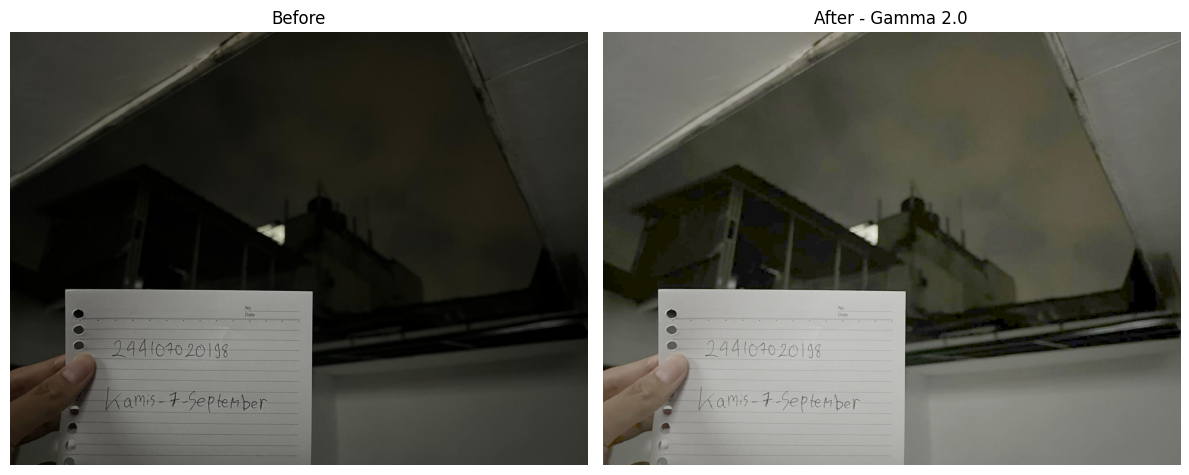

In [62]:
gamma = 2.0  # ganti sesuai hasil terbaik

img_norm = img_rgb / 255.0
hasil = 255 * (img_norm ** (1 / gamma))
hasil = np.uint8(hasil)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hasil)
plt.title(f'After - Gamma {gamma}')
plt.axis('off')

plt.tight_layout()
plt.show()

1. Metode yang dipilih
Metode yang dipilih adalah Gamma Correction.

2. Alasan pemilihan
Gamma Correction dipilih karena citra NIGHT1.jpeg memiliki pencahayaan yang rendah atau gelap. Metode ini digunakan untuk meningkatkan kecerahan sehingga detail pada bagian gelap lebih mudah terlihat.

3. Menentukan parameter terbaik
Pada percobaan awal, nilai gamma ditentukan berdasarkan parameter NIM, yaitu gamma = 0,4. Namun, setelah diterapkan pada citra NIGHT1.jpeg, hasil citra justru menjadi semakin gelap. Hal ini menunjukkan bahwa nilai tersebut kurang sesuai untuk kondisi citra malam yang digunakan.

Selanjutnya dilakukan percobaan dengan beberapa nilai gamma yang lebih besar, yaitu 1,5, 2,0, 2,5, dan 3,0. Hasil dari masing-masing nilai dibandingkan untuk menentukan parameter yang dapat meningkatkan kecerahan tanpa menghilangkan terlalu banyak detail.

4. Menghasilkan citra before-after
Setelah mendapatkan nilai gamma yang paling sesuai, citra asli (Before) dibandingkan dengan citra hasil Gamma Correction (After). Perbandingan tersebut digunakan untuk menunjukkan perubahan kecerahan dan detail pada citra.

Kesimpulan:
Percobaan awal dengan gamma = 0,4 berdasarkan NIM menghasilkan citra yang semakin gelap, sehingga parameter tersebut tidak digunakan sebagai parameter terbaik. Parameter kemudian ditentukan berdasarkan hasil percobaan pada citra NIGHT1.jpeg itu sendiri.